In [3]:
import dataclasses

@dataclasses.dataclass
class Tile:
    qubits: list[complex]
    color: str



In [4]:
def make_color_code_tiles(*, base_data_width: int) -> list[Tile]:
    if not (base_data_width % 2 == 1 and base_data_width >= 3):
        raise ValueError(f"{base_data_width=} wasn't an odd number at least as large as 3.")
    w = base_data_width * 2 - 1

    def is_in_bounds(q: complex) -> bool:
        # Check that it's within the intersection of the three boundary half planes.
        if q.imag < 0:
            # Too far up.
            return False
        if q.imag * 2 > q.real * 3:
            # Too far downleft.
            return False
        if q.imag * 2 > (w - q.real) * 3:
            # Too far downright.
            return False
        return True

    # Make a hexagonal tiling, cutting away any vertices that are out of bounds.
    tiles = []
    hexagon_offsets = [-1, +1j, +1j + 1, +2, -1j + 1, -1j]
    for x in range(1, w, 2):
        for y in range((x // 2) % 2, w, 2):
            q = x + 1j * y
            tile = Tile(
                color=['red', 'green', 'blue'][y % 3],
                qubits=[
                    q + d
                    for d in hexagon_offsets
                    if is_in_bounds(q + d)
                ],
            )
            # Only keep the hexagons and trapezoids.
            # No empty tiles, or single-point tiles, or etc.
            if len(tile.qubits) in [4, 6]:
                tiles.append(tile)

    return tiles    

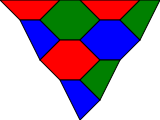

In [5]:
class ShowAsSvg:
    def __init__(self, svg: str):
        self.svg = svg
    def _repr_svg_(self) -> str:
        return self.svg

def draw_tiles_as_svg(tiles: list[Tile]) -> ShowAsSvg:
    # Size the SVG to fit the tiles.
    max_r = max(q.real for tile in tiles for q in tile.qubits)
    max_i = max(q.imag for tile in tiles for q in tile.qubits)
    svg = f'<svg width="{max_r * 20}" height="{max_i * 20}" xmlns="http://www.w3.org/2000/svg">\n'

    # Add each tile to the SVG as a filled shape.
    for tile in tiles:
        pts = [q * 20 for q in tile.qubits]
        p = pts[-1]
        d = f'M{p.real},{p.imag}'
        for p in pts:
            d += f' L{p.real},{p.imag}'
        svg += f'<path d="{d}" fill="{tile.color}" stroke="black" />\n'
    
    svg += '</svg>'
    
    return ShowAsSvg(svg)

draw_tiles_as_svg(make_color_code_tiles(base_data_width=5))

In [7]:
import stim
from typing import Literal

def make_color_code_circuit(
    *,
    obs_basis: Literal['X', 'Y', 'Z'],
    base_data_width: int,
    rounds: int,
    noise_strength: float,
) -> stim.Circuit:
    """Creates a color code circuit with a phenomenological noise model.

    The circuit's detectors are annotated so that Chromobius can decode them.

    Args:
        obs_basis: The basis of the observable to prepare and verify at the end of the circuit.
        base_data_width: The number of data qubits along one side of the patch.
        rounds: The number of times to apply depolarizing noise. One more than the number of
            times to apply measurement noise.
        noise_strength: The strength of the depolarizing noise applied to the data qubits,
            and also the probability of noisy measurements reporting the wrong result.

    Returns:
        The created circuit.
    """

    def mpp_targets(
        qubits: list[complex],
        basis: Literal['X', 'Y', 'Z']
    ) -> list[stim.GateTarget]:
        """Makes a pauli product for an MPP instruction."""
        target_b = {'X': stim.target_x, 'Y': stim.target_y, 'Z': stim.target_z}[basis]
        indices = sorted(q2i[q] for q in qubits)
        targets = []
        for k in indices:
            targets.append(target_b(k))
            targets.append(stim.target_combiner())
        targets.pop()
        return targets

    def measure_observables() -> stim.Circuit:
        """Make instructions to measure an observable of the color code."""
        c = stim.Circuit()
        c.append("MPP", mpp_targets(sorted_qubits, obs_basis))
        c.append("OBSERVABLE_INCLUDE", stim.target_rec(-1), 0)
        return c
        
    def measure_stabilizers(
        *,
        data_noise_after: bool,
        measure_noise: bool,
        include_detectors: bool,
    ) -> stim.Circuit:
        """Make instructions to measure the stabilizers of the color code."""
        c = stim.Circuit()

        # Measure every stabilizer.
        for basis in ['X', 'Z']:
            for tile in tiles:
                c.append("MPP", mpp_targets(tile.qubits, basis), noise_strength if measure_noise else None)
        
        # Compare the measurements to the previous round to produce detection events.
        if include_detectors:
            num_stabilizers = len(tiles) * 2
            for xz in range(2):
                for k, tile in enumerate(tiles):
                    center = sum(tile.qubits) / len(tile.qubits)
                    chromobius_color = {'red': 0, 'green': 1, 'blue': 2}[tile.color]
                    chromobius_annotation = chromobius_color + xz*3
                    offset = xz * len(tiles) + k
                    c.append("DETECTOR", [
                        stim.target_rec(-num_stabilizers + offset), 
                        stim.target_rec(-num_stabilizers*2 + offset),
                    ], [center.real, center.imag, 0, chromobius_annotation])

        # End the round.
        if data_noise_after:
            c.append("DEPOLARIZE1", range(len(all_qubits)), noise_strength)
        c.append("SHIFT_COORDS", [], [0, 0, 1])
        c.append("TICK")

        return c

    tiles = make_color_code_tiles(base_data_width=base_data_width)
    circuit = stim.Circuit()

    # Index the qubit coordinates and put coordinate data in the circuit.
    all_qubits = {q for tile in tiles for q in tile.qubits}
    sorted_qubits = sorted(all_qubits, key=lambda q: (q.real, q.imag))
    q2i = {q: i for i, q in enumerate(sorted_qubits)}
    for q, i in q2i.items():
        circuit.append("QUBIT_COORDS", [i], [q.real, q.imag])

    # Use the helper methods you just defined to build the rounds and combine them into a full circuit.
    circuit += measure_observables()
    circuit += measure_stabilizers(data_noise_after=True, measure_noise=False, include_detectors=False)
    circuit += (rounds - 1) * measure_stabilizers(data_noise_after=True, measure_noise=True, include_detectors=True)
    circuit += measure_stabilizers(data_noise_after=False, measure_noise=False, include_detectors=True)
    circuit += measure_observables()
    
    return circuit

make_color_code_circuit(
    obs_basis='X',
    base_data_width=3,
    rounds=2,
    noise_strength=1e-3
)

stim.Circuit('''
    QUBIT_COORDS(0, 0) 0
    QUBIT_COORDS(1, 1) 1
    QUBIT_COORDS(2, 1) 2
    QUBIT_COORDS(2, 3) 3
    QUBIT_COORDS(3, 0) 4
    QUBIT_COORDS(3, 2) 5
    QUBIT_COORDS(4, 0) 6
    MPP X0*X1*X2*X3*X4*X5*X6
    OBSERVABLE_INCLUDE(0) rec[-1]
    MPP X0*X1*X2*X4 X1*X2*X3*X5 X2*X4*X5*X6 Z0*Z1*Z2*Z4 Z1*Z2*Z3*Z5 Z2*Z4*Z5*Z6
    DEPOLARIZE1(0.001) 0 1 2 3 4 5 6
    SHIFT_COORDS(0, 0, 1)
    TICK
    MPP(0.001) X0*X1*X2*X4 X1*X2*X3*X5 X2*X4*X5*X6 Z0*Z1*Z2*Z4 Z1*Z2*Z3*Z5 Z2*Z4*Z5*Z6
    DETECTOR(1.5, 0.5, 0, 0) rec[-6] rec[-12]
    DETECTOR(2, 1.75, 0, 2) rec[-5] rec[-11]
    DETECTOR(3, 0.75, 0, 1) rec[-4] rec[-10]
    DETECTOR(1.5, 0.5, 0, 3) rec[-3] rec[-9]
    DETECTOR(2, 1.75, 0, 5) rec[-2] rec[-8]
    DETECTOR(3, 0.75, 0, 4) rec[-1] rec[-7]
    DEPOLARIZE1(0.001) 0 1 2 3 4 5 6
    SHIFT_COORDS(0, 0, 1)
    TICK
    MPP X0*X1*X2*X4 X1*X2*X3*X5 X2*X4*X5*X6 Z0*Z1*Z2*Z4 Z1*Z2*Z3*Z5 Z2*Z4*Z5*Z6
    DETECTOR(1.5, 0.5, 0, 0) rec[-6] rec[-12]
    DETECTOR(2, 1.75, 0, 2) rec[-5] rec